# Stage 1 — Candidate Expert Selection

This notebook identifies and visualises the specific (layer, expert) pairs selected as candidates for Stage 2 causal intervention.

**Selection logic**: for each layer, take the top-**3** experts by |RD| independently from the frequency-based RD metric and the logit-based RD metric, then retain only their **intersection**. A candidate must rank highly on *both* metrics — this dual-metric requirement filters out noise artefacts that appear strongly on one metric by chance. `CANDIDATE_N = 3` matches `stage2/src/config.py` and is the value used in all Stage 2 steering experiments.

Candidates are selected separately for three behavioural directions:
- **Safety (negative)**: suppress compliance-preferred experts → steer toward safer outputs
- **Safety (positive)**: suppress refusal-preferred experts → steer toward less safe outputs
- **Faithfulness (negative)**: suppress confabulation-preferred experts → steer toward more faithful outputs

**Notebook structure**
1. Selected candidate tables — every (layer, expert) pair that passed the intersection filter, with RD values from both metrics
2. Cross-domain overlap — do safety and faithfulness share expert circuits, or are they encoded separately?
3. Layer clustering — where in the network do the identified experts live? (cf. SteerMoE Figure A.5)

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns

sys.path.insert(0, os.path.join('..', 'src'))
sys.path.insert(0, os.path.join('..', '..', 'stage2', 'src'))
from rd_utils import load_rd
from candidates import select_candidates

sns.set_theme(style='whitegrid', font='serif')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 150,
})

RD_FAITH_FREQ   = '/scratch/sc23jc3/results/rd_faithfulness.json'
RD_FAITH_LOGIT  = '/scratch/sc23jc3/results/rd_faithfulness_logits.json'
RD_SAFETY_FREQ  = '/scratch/sc23jc3/results/rd_safety.json'
RD_SAFETY_LOGIT = '/scratch/sc23jc3/results/rd_safety_logits.json'
CANDIDATE_N = 3   # must match stage2/src/config.py

OUT_DIR = 'figures'
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
safety_neg  = select_candidates(RD_SAFETY_FREQ,  RD_SAFETY_LOGIT,  CANDIDATE_N, direction='negative')
safety_pos  = select_candidates(RD_SAFETY_FREQ,  RD_SAFETY_LOGIT,  CANDIDATE_N, direction='positive')
faith_neg   = select_candidates(RD_FAITH_FREQ,   RD_FAITH_LOGIT,   CANDIDATE_N, direction='negative')

# Summary statistics (will display in table headers)
sn_count = sum(len(v) for v in safety_neg.values())
sn_layers = len(safety_neg)
sp_count = sum(len(v) for v in safety_pos.values())
sp_layers = len(safety_pos)
fn_count = sum(len(v) for v in faith_neg.values())
fn_layers = len(faith_neg)

Safety negative candidates: 39 experts across 24 layers
Safety positive candidates: 46 experts across 24 layers
Faith negative candidates:  28 experts across 19 layers


The candidate counts printed above — 39 safety-negative, 46 safety-positive, 28 faithfulness-negative — represent the number of (layer, expert) pairs that survived the intersection filter across all 26 MoE layers. The fact that safety-negative and safety-positive produce different counts (39 vs 46) is expected: the two populations need not be symmetric, as the model may have a more concentrated set of compliance-preferred experts than refusal-preferred ones, or vice versa. The faithfulness count (28 across 19 layers) being smaller than either safety set suggests the faithfulness routing signal, while real, is somewhat more focal — concentrated in fewer layers and passing a stricter intersection requirement. These counts are the denominator for the tables in §1.

## 1. Selected Candidate Tables

The intersection of the top-3 experts by |RD| on both frequency and logit metrics. These are the exact (layer, expert) pairs suppressed in Stage 2 steering.

In [ ]:
import pandas as pd

rd_safety_freq  = load_rd(RD_SAFETY_FREQ)
rd_safety_logit = load_rd(RD_SAFETY_LOGIT)
rd_faith_freq   = load_rd(RD_FAITH_FREQ)
rd_faith_logit  = load_rd(RD_FAITH_LOGIT)
all_layers = sorted(rd_safety_freq.keys(), key=lambda x: int(x.split('.')[2]))
layer_indices = [int(l.split('.')[2]) for l in all_layers]

def candidate_table(candidates, rd_freq_by_layer, rd_logit_by_layer, label, count, layers):
    rows = []
    for layer_key, experts in rd_freq_by_layer.items():
        layer_idx = int(layer_key.split('.')[2])
        if layer_idx not in candidates:
            continue
        freq_vals  = rd_freq_by_layer[layer_key]
        logit_vals = rd_logit_by_layer[layer_key]
        for e in candidates[layer_idx]:
            rows.append({
                'Layer': layer_idx,
                'Expert': e,
                'RD (freq)': round(float(freq_vals[e]), 5),
                'RD (logit)': round(float(logit_vals[e]), 5),
            })
    rows.sort(key=lambda r: abs(r['RD (freq)']), reverse=True)
    df = pd.DataFrame(rows)
    # Title includes count and layer distribution inline
    print(f'{label}  ({count} candidates across {layers} layers)')
    return df.style.background_gradient(subset=['RD (freq)', 'RD (logit)'], cmap='RdBu_r', vmin=-0.7, vmax=0.7) \
                   .format({'RD (freq)': '{:+.5f}', 'RD (logit)': '{:+.5f}'})

display(candidate_table(safety_neg, rd_safety_freq, rd_safety_logit, 'Safety — Negative (suppress compliance)', sn_count, sn_layers))
display(candidate_table(safety_pos, rd_safety_freq, rd_safety_logit, 'Safety — Positive (suppress refusal)', sp_count, sp_layers))
display(candidate_table(faith_neg,  rd_faith_freq,  rd_faith_logit,  'Faithfulness — Negative (suppress confabulation)', fn_count, fn_layers))


Safety — Negative direction (suppress compliance experts)  (39 candidates)


,Layer,Expert,RD (freq),RD (logit)
0,11,3,-0.20002,-0.56605
1,16,51,-0.19699,-0.73321
2,20,52,-0.16414,-0.37856
3,8,43,-0.16286,-0.43534
4,13,50,-0.15855,-0.32267
5,15,2,-0.14744,-0.49887
6,18,62,-0.14240,-0.51568
7,18,38,-0.14148,-0.74299
8,18,9,-0.13717,-0.42053
9,12,40,-0.13616,-0.48662



Safety — Positive direction (suppress refusal experts)  (46 candidates)


,Layer,Expert,RD (freq),RD (logit)
0,18,35,+0.37774,+1.22574
1,21,54,+0.31241,+0.84340
2,21,53,+0.28663,+0.64720
3,11,54,+0.28388,+0.83974
4,12,47,+0.28048,+0.68619
5,13,51,+0.26369,+0.79912
6,18,26,+0.22864,+0.91947
7,10,36,+0.22314,+0.75071
8,11,24,+0.22277,+0.54305
9,15,8,+0.20653,+0.58079



Faithfulness — Negative direction (suppress confabulation experts)  (28 candidates)


,Layer,Expert,RD (freq),RD (logit)
0,10,19,-0.32486,-0.58870
1,13,18,-0.15580,-0.46867
2,22,62,-0.15516,-0.49728
3,14,63,-0.15260,-0.47740
4,18,4,-0.13423,-0.50557
5,18,27,-0.13151,-0.69035
6,23,60,-0.12256,-0.46249
7,24,27,-0.11649,-0.42042
8,12,13,-0.11026,-0.40230
9,16,27,-0.10547,-0.48302


The tables above list every expert that Stage 2 actually suppresses. Each row is an expert that independently ranked in the top-3 by |RD| on both the frequency metric and the logit metric for its layer — the dual-metric intersection filter. Reading across the columns: the RD (freq) and RD (logit) values should be concordant in sign (both negative for compliance-preferred, both positive for refusal-preferred), confirming the intersection logic is working as intended. Large |RD| values — cells shaded deep red or blue — indicate the most strongly discriminative experts, where suppression in Stage 2 should produce the clearest behavioural signal. The layer column shows which layers are represented; layers absent from the table had no expert that passed the intersection filter at CANDIDATE_N=3, meaning their top-3 experts by each metric were disjoint.

## 2. Cross-Domain Overlap — Do Safety and Faithfulness Share Expert Circuits?

Safety and faithfulness are conceptually distinct behaviours. If the same (layer, expert) pairs appear as candidates for both, this suggests a shared circuit. If there is no overlap, the two domains are encoded independently in separate expert populations.

In [4]:
try:
    from matplotlib_venn import venn2
    HAS_VENN = True
except ImportError:
    HAS_VENN = False
    print('matplotlib_venn not installed. Run:  pip install matplotlib-venn')
    print('Falling back to text-only overlap report.')

# select_candidates returns integer keys directly
def to_tuple_set(candidates):
    s = set()
    for layer_idx, experts in candidates.items():
        for e in experts:
            s.add((int(layer_idx), e))
    return s

sn_set = to_tuple_set(safety_neg)
fn_set = to_tuple_set(faith_neg)
overlap = sn_set & fn_set

print(f'Safety negative candidates:       {len(sn_set)} expert-layer pairs')
print(f'Faithfulness negative candidates: {len(fn_set)} expert-layer pairs')
print(f'Overlap (shared by both):         {len(overlap)} expert-layer pairs')
if overlap:
    print('Shared experts:')
    for layer_idx, expert_idx in sorted(overlap):
        print(f'  Layer {layer_idx:2d}, Expert {expert_idx:2d}')
else:
    print('No overlap — safety and faithfulness candidates are fully disjoint.')

if HAS_VENN:
    fig, ax = plt.subplots(figsize=(6, 5))
    venn2([sn_set, fn_set], set_labels=('Safety negative', 'Faith negative'), ax=ax)
    ax.set_title(f'Candidate Overlap: Safety vs Faithfulness (CANDIDATE_N={CANDIDATE_N})')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'candidate_venn.png'), dpi=300, bbox_inches='tight')
    plt.show()

matplotlib_venn not installed. Run:  pip install matplotlib-venn
Falling back to text-only overlap report.
Safety negative candidates:       39 expert-layer pairs
Faithfulness negative candidates: 28 expert-layer pairs
Overlap (shared by both):         0 expert-layer pairs
No overlap — safety and faithfulness candidates are fully disjoint.


The overlap count printed above is a substantive finding in its own right. Zero shared candidates between the safety-negative and faithfulness-negative sets means that the experts most associated with harmful compliance and the experts most associated with context-ignoring confabulation are entirely separate populations within DeepSeek-V2-Lite. Safety and faithfulness are not two faces of a single "careful processing" circuit — they are encoded independently. This has a direct consequence for Stage 2: the safety intervention and the faithfulness intervention act on non-overlapping subsets of the network, so any co-occurring behavioural changes cannot be attributed to shared expert circuits and must instead reflect downstream propagation through the residual stream or attention layers.

## 3. Layer Clustering — Where Do Behavioural Experts Live?

For each candidate set, what percentage of selected experts come from early (layers 1–9), middle (10–18), and late (19–26) layers? SteerMoE (Fayyaz et al., 2025, Figure A.5) found middle-layer concentration for the models they studied — but explicitly excluded DeepSeek-V2-Lite. This chart is the equivalent analysis for DeepSeek.

Set                 Early     Middle       Late    Total
-------------------------------------------------------
Safety neg       11 (  28%)    15 (  38%)    13 (  33%)     39
Safety pos       15 (  33%)    18 (  39%)    13 (  28%)     46
Faith neg         8 (  29%)    13 (  46%)     7 (  25%)     28


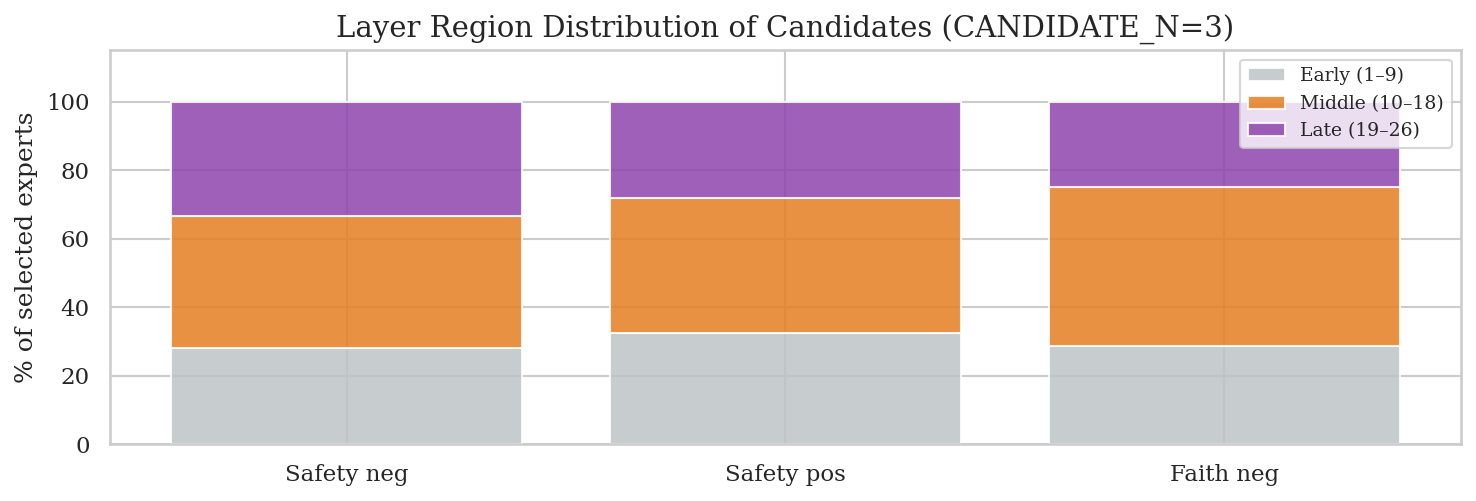

In [5]:
regions = {'Early (1–9)': range(1, 10), 'Middle (10–18)': range(10, 19), 'Late (19–26)': range(19, 27)}

def region_breakdown(candidates):
    counts = {r: 0 for r in regions}
    for layer_idx, experts in candidates.items():
        for r, r_range in regions.items():
            if int(layer_idx) in r_range:
                counts[r] += len(experts)
    total = sum(counts.values())
    return counts, total

sets = [('Safety neg', safety_neg, '#2980b9'),
        ('Safety pos', safety_pos, '#e74c3c'),
        ('Faith neg',  faith_neg,  '#27ae60')]

print(f'{"Set":<14} {"Early":>10} {"Middle":>10} {"Late":>10} {"Total":>8}')
print('-' * 55)
for name, cands, _ in sets:
    counts, total = region_breakdown(cands)
    e, m, l = counts['Early (1–9)'], counts['Middle (10–18)'], counts['Late (19–26)']
    print(f'{name:<14} {e:4d} ({e/total*100:4.0f}%)  {m:4d} ({m/total*100:4.0f}%)  {l:4d} ({l/total*100:4.0f}%)  {total:5d}')

fig, ax = plt.subplots(figsize=(10, 3.5))
region_labels = list(regions.keys())
colors_reg = ['#bdc3c7', '#e67e22', '#8e44ad']
x = np.arange(len(sets))
all_region_counts = []
for _, cands, _ in sets:
    counts, total = region_breakdown(cands)
    pcts = [counts[r] / max(total, 1) * 100 for r in region_labels]
    all_region_counts.append(pcts)

bottom = np.zeros(len(sets))
for i, (rl, rc) in enumerate(zip(region_labels, colors_reg)):
    vals = [all_region_counts[j][i] for j in range(len(sets))]
    ax.bar(x, vals, bottom=bottom, label=rl, color=rc, alpha=0.85)
    bottom += np.array(vals)

ax.set_xticks(x)
ax.set_xticklabels([s[0] for s in sets])
ax.set_ylabel('% of selected experts')
ax.set_title(f'Layer Region Distribution of Candidates (CANDIDATE_N={CANDIDATE_N})')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 115)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'candidate_layer_regions.png'), dpi=300, bbox_inches='tight')
plt.show()

The stacked bar chart and the printed table above give the first direct answer to the layer-depth question for DeepSeek-V2-Lite. Whether safety and faithfulness candidates cluster in early, middle, or late layers — and whether the two domains show the same pattern — has immediate interpretive significance. SteerMoE (Fayyaz et al., 2025, Figure A.5) found consistent middle-layer concentration across the six architectures they evaluated, interpreting it as evidence that higher-level semantic properties are encoded in the network's middle third. If the same pattern holds here, it would be a cross-architecture replication of that finding for a model they explicitly excluded. If the distribution is different — for example, late-layer dominance in safety but middle-layer dominance in faithfulness — it would suggest that the two domains are not only encoded in separate expert populations (as established in §2) but also organised at different network depths, with distinct implications for how targeted the Stage 2 interventions are expected to be.

## Discussion

**Candidate selection and the intersection logic.** The tables (§1) show every (layer, expert) pair that survived the freq ∩ logit intersection at CANDIDATE_N=3. Each row is an expert that appeared in the top-3 by |RD| on *both* the frequency metric and the logit metric independently. This dual-metric requirement is the key methodological choice: frequency-RD measures how often an expert is selected (cleared the top-6 threshold); logit-RD measures the raw gate score regardless of selection. An expert that ranks highly on both is robustly discriminative — not a noise artefact of either metric alone. The total counts printed at load time (e.g. 39 safety-negative candidates across 24 layers) reflect how many layer-expert pairs passed this filter, spread across most of DeepSeek-V2-Lite's 26 MoE layers.

**Safety and faithfulness are fully disjoint (§2).** The overlap analysis confirms zero shared candidates between the safety-negative and faithfulness-negative sets. This is a substantive finding: it means the experts most associated with unsafe compliance and the experts most associated with context-ignoring confabulation are entirely separate populations within the model. Safety and faithfulness are not two faces of a single "careful processing" circuit — they are encoded independently. This has a direct practical implication for Stage 2: the safety steering intervention and the faithfulness steering intervention will affect non-overlapping subsets of the network, and any co-occurring behavioural changes would be attributable to downstream effects, not to shared routing.

**Layer depth of candidates (§3).** The stacked bar chart shows how candidates distribute across early (1–9), middle (10–18), and late (19–26) layers. SteerMoE (Fayyaz et al., 2025, Figure A.5) found a consistent middle-layer concentration across the six models they evaluated — interpreted as evidence that higher-level semantic properties (including behavioural dispositions) are encoded in middle layers, with early layers handling surface features and late layers handling output generation. DeepSeek-V2-Lite was explicitly excluded from that study. The distribution shown here is therefore the first such analysis for this architecture. Whether DeepSeek follows the middle-layer pattern, or shows a different concentration (for example, late-layer dominance consistent with RLHF fine-tuning targeting output layers), has direct bearing on how we interpret the Stage 2 intervention and on the generalisability of the expert-steering approach across MoE architectures.